# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Anna Stroeve
* Username: agstroeve
* Student number: s5995035
* Group (AS1, etc.): AS2

-----

In [1]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

Composed path: /Users/users/agstroeve/PROGNUM-repo/Task5/rotcur.dat
max: 1311.6606503581597


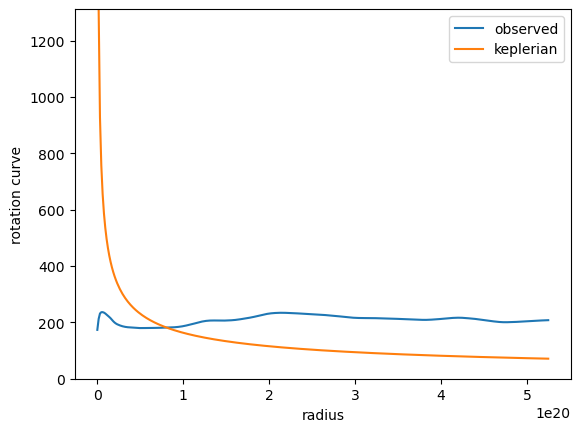

In [12]:
import numpy as np 
from pathlib import Path
import os 
from matplotlib.pyplot import figure, subplots, show
from math import sqrt

tilde_path = os.path.expanduser('~') 
subdirectory = 'PROGNUM-repo'
subdirectory2 = 'Task5'
rotcur = 'rotcur.dat'
OSpath = f"{tilde_path}/{subdirectory}/{subdirectory2}/{rotcur}"   #write the path to where the file (rotcur.txt) can be found 
path = Path(OSpath)
print(f"Composed path: {path}")
    
mode = 'r'  # reading mode 
r = open(rotcur, mode)  # open the file 

radius, velocity = np.loadtxt(path, comments="#", unpack=True)  # turn the radius and velocity into arrays 
radius_m = radius * (3.086e19) #convert radius, which is now kpc, to meters

G = 6.67*10**-11  #gravitational constant 
Msun = 1.99*10**30  # solar mass
M = Msun * 2*10**10   # mass of NGC 6946
new_r = np.delete(radius_m,0)  # delete the first value of radius as it is 0 (cannot divide by zero)
keplerian = [sqrt((G*M)/ num) for num in new_r]  #formula for the keplerian 
keplerian = np.array(keplerian)/1000 #convert keplerian to km/s

maxi = np.max(keplerian)
print(f"max: {maxi}")

np.savetxt('keplerian.txt', np.column_stack((new_r, keplerian)), fmt='%.18e', delimiter=' ', newline='\n',  
              header='', footer='', comments='# ')  #save the keplerian into 2 columns, for radius and velocity
kep_r, kep_v = np.loadtxt('keplerian.txt', unpack=True)  # load the keplerian file, radius and velocity seperately

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.set(xlabel='radius', ylabel='rotation curve' )
frame.plot(radius_m, velocity)
frame.plot(kep_r, kep_v)
frame.set_ylim(0, np.max(kep_v))
frame.legend(['observed', 'keplerian'])
show()   # plot a graph of the keplerian data

<div class='alert alert-warning'>
    <b>Feedback</b> <br>

You had to plot both curves in 1 plot. <b>[0.5pt deducted from total grade.]</b>

No xlabel, ylabel, legend or correct y-limit. <b>[0.5pt deducted from total grade.]</b>

Incorrect unit conversion. Distances are in parsecs, Gravitation constant has $m^3$ in it, and the speed is in km/s. <b>[0.5pt deducted from total grade.]</b>

You are not using all the data from `keplerian_curve.txt` to plot your graph. While you did save and load `kep_file`, you did it incorrectly. We expect you to first save the rotation velocities and radius in 1 `keplerian_curve.txt`. And then load both value's back in using `np.loadtxt`. <b>[0.5pt deducted from total grade.]</b>
</div>

In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 2

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

[[ 0.47255258 -0.63514713 -0.75034378 ... -0.1283917  -0.23975491
  -0.16266023]
 [ 1.85760246 -1.86566834  1.61111153 ...  0.89090135  0.01122088
  -0.6782407 ]
 [ 0.18483017 -1.22166043 -0.43211523 ... -0.63264642 -2.47727195
  -0.36175614]
 ...
 [-1.42723442 -0.19706025  1.6957773  ...  0.19537893  0.56874761
   1.97685285]
 [ 1.19935905 -0.29966986  1.31006554 ...  0.3618493  -0.35369442
   2.67199223]
 [-1.00535223  1.55489304 -0.81906574 ... -1.79192967 -0.66215508
   0.91979391]]


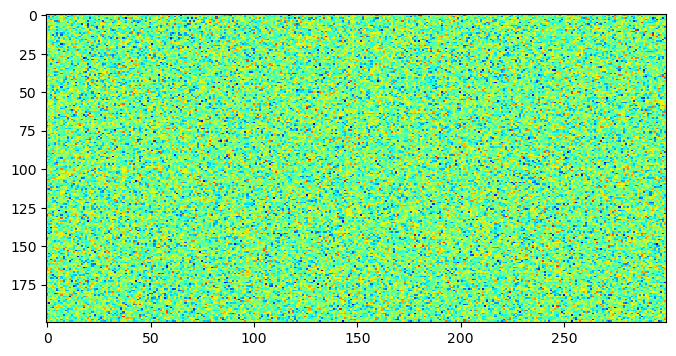

mean: -0.013309619319232873
standard deviation: 1.0560293237378713


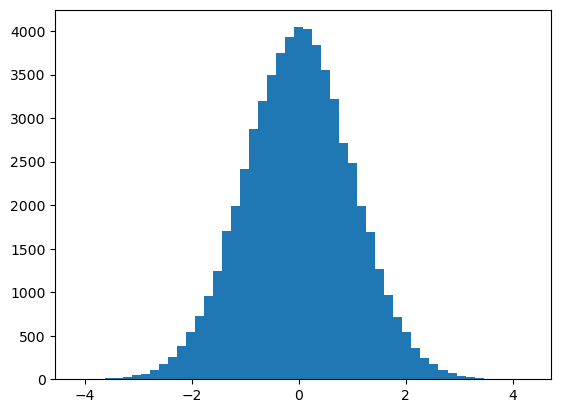

In [41]:
import numpy as np
import matplotlib.pyplot as plt
arr_c = np.array(np.random.normal(0,1,60000)).reshape(200,300)  #array of 60000 numbers from Gaussian distribution, size 200 by 300
print(arr_c)
plt.figure(figsize=(8,4))
plt.imshow(arr_c, interpolation='none', cmap='jet', aspect='auto')  #plot arr_c, colormap jet 
plt.show()
arr_s = arr_c[20:50,20:50]  #slice of the array 
print(f"mean: {np.mean(arr_s)}")  #mean of the slice
print(f"standard deviation: {np.std(arr_s)}")   #standard deviation of the slice

#the calculated mean is around 0, which is to be expected as I am calculating the mean of a Gaussian distribution; for a 
#Gaussian distribution the mean is 0. The same is true for the standard deviation which is around 1. 

fl_c = np.ndarray.flatten(arr_c)
plt.hist(fl_c, bins=50)  #histogram of all values
plt.show()

<div class='alert alert-warning'>
    <b>Feedback</b> <br>

Your figure is not u inches wide and 4 inches high. <b>[0.5pt deducted from total grade.]</b>

You did not comment on the calculated mean and standard deviation of youe 30x30 slice. <b>[0.5pt deducted from total grade.]</b>

Incorrect histogram. See the tip, you have to do something with ravel or flatten. <b>[0.5pt deducted from total grade.]</b>
</div>

In [5]:
# Leave unaltered
totalpoints += 3
currentpoints += 1.5

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

Area: 18.84955592153876
Perimeter: 15.865437575563961
Center:(0, 0), semi_major:3, semi_minor:2, angle: 0


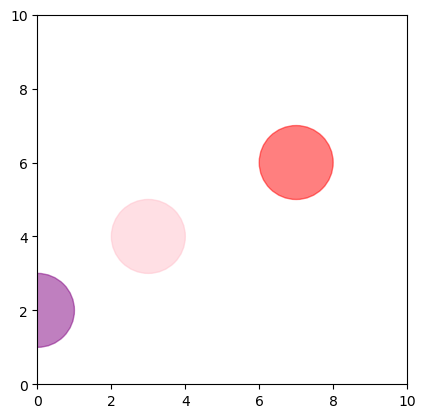

In [66]:
from matplotlib.patches import Ellipse
from math import pi, sqrt
import random
import matplotlib.pyplot as plt 


class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
        assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
        self.semi_major = semi_major
        self.semi_minor = semi_minor
        self.XY = (xc, yc)                  # MPL requires center as a tuple
        self.angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
        height = 2.0*self.semi_major        # height: is along vertical axis for an unrotated ellipse
        width  = 2.0*self.semi_minor        # width:  is along horizontal axis for an unrotated ellipse
        super().__init__(self.XY, width, height, angle=self.angle_mpl, **args)  
        
    def area(self): 
        z = self.semi_major * self.semi_minor * pi  
        return z 
    def perimeter(self):
        x = pi*(3*(self.semi_major+self.semi_minor)-sqrt(((3*self.semi_major)+self.semi_minor)*(self.semi_major+(3*self.semi_minor))))
        return x 
    def __str__(self):
        return f"Center:{self.XY}, semi_major:{self.semi_major}, semi_minor:{self.semi_minor}, angle: {self.angle_mpl}" 
        #return the calculated/input values as a string 
        
class MyCircle(AstroEllipse):
    def __init__(self, center, radius, alpha, color, **args):
        super().__init__(center[0], center[1], radius, radius, 0, facecolor=color, edgecolor=color, alpha=alpha, **args)

fig, ax = plt.subplots()

center1 = (random.randint(0,10), random.randint(0,10))  #center for each of the circles 
center2 = (random.randint(0,10), random.randint(0,10))
center3 = (random.randint(0,10), random.randint(0,10))
radius1 = random.randint(1, 2)  #radius for each of the circles 
radius2 = random.randint(1, 2)
radius3 = random.randint(1, 2)

circle1 = MyCircle(center1, radius1, alpha=0.5, color='red')
circle2 = MyCircle(center2, radius2, alpha=0.5, color='pink')
circle3 = MyCircle(center3, radius3, alpha=0.5, color='purple')

ax.add_patch(circle1)   #make the circles show up in the plot 
ax.add_patch(circle2) 
ax.add_patch(circle3)

ellipse1 = AstroEllipse(0, 0, 3, 2, 0)  #ellipse with semimajor axis 3 and semiminor axis 2
print("Area:", ellipse1.area())  #call the methods separately 
print("Perimeter:", ellipse1.perimeter())
print(ellipse1)  #print everything as a string 

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect(1)  #make the plot a square 
plt.show()

<div class='alert alert-warning'>
    <b>Feedback</b> <br>

I can't really reward any points since the code is not working. But feel free to try again in the correction.

A tip, try to read the material in Brightspace. The reason why you get the error about not having a attribute is because in Object Oriented Programming, you always need to reference variables properly. In this case you will need to fix the code by correctly using `self`.
</div>

In [7]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

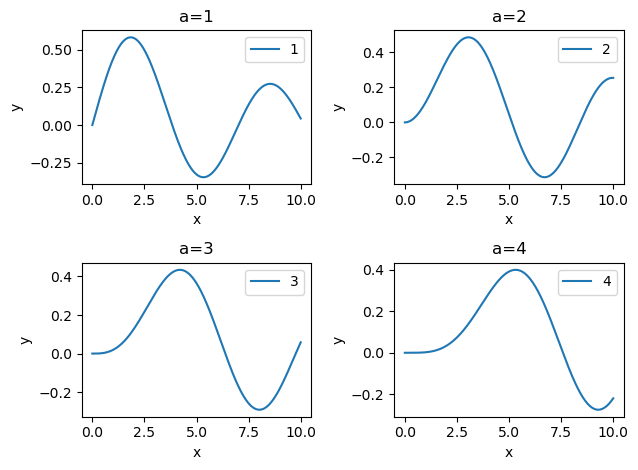

In [98]:
import matplotlib.pyplot as plt 
from scipy.special import jv 
import numpy as np 

x = np.linspace(0, 10, 1000)

fig, axs = plt.subplots(2, 2)

y1 = jv(1, x)
y2 = jv(2, x)
y3 = jv(3, x)
y4 = jv(4, x)
    
    
axs[0,0].plot(x, y1)
axs[0,0].set_title('a=1')
axs[0,0].set_xlabel('x')
axs[0,0].set_ylabel('y')
axs[0,0].legend('1')

axs[0,1].plot(x, y2)
axs[0,1].set_title('a=2')
axs[0,1].set_xlabel('x')
axs[0,1].set_ylabel('y')
axs[0,1].legend('2')

axs[1,0].plot(x, y3)
axs[1,0].set_title('a=3')
axs[1,0].set_xlabel('x')
axs[1,0].set_ylabel('y')
axs[1,0].legend('3')

axs[1,1].plot(x, y4)
axs[1,1].set_title('a=4')
axs[1,1].set_xlabel('x')
axs[1,1].set_ylabel('y')
axs[1,1].legend('4')


plt.tight_layout()  #change the layout so the x- and y-label are showing 

plt.show()  

fig.savefig("Bessel.pdf", transparent=True)

<div class='alert alert-warning'>
    <b>Feedback</b> <br>

Can't really award points. You don't need to use OOP (Object Oriented Programming) to solve this question.

I'd recommend you first to try to see if you are able to plot 1 graph of the bessel function. Then think about how one can make a mosaic plot. You can find plenty of information online about mosiac plots!
</div>

In [102]:
from IPython.display import IFrame

IFrame("Bessel.pdf", width=600, height=400)

In [9]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

<div class='alert alert-warning'>
    <b>Feedback</b> <br>

Not attempted questions cannot be corrected in the correction unfortunately. 
</div>

In [10]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [11]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")

Total number of points: 18. Student score: 3.5.  Task Grade = 1.9
